# Paper Figures
ANN and task benchmark figures for NeurIPS 1-column format.

In [2]:
import os
import json
import ast
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

matplotlib.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'legend.title_fontsize': 8,
    'axes.titlesize': 9,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

RESULTS_DIR = './ann/results'
OUTPUT_DIR = './figures/paper'
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATASET_PRETTY = {
    'fashion_mnist': 'Fashion-MNIST',
    'glove_100': 'Glove-100',
    'last_fm': 'LastFM',
    'ny_times': 'NY Times',
    'sift': 'SIFT',
}

In [5]:
def parse_config(name):
    with open(os.path.join(RESULTS_DIR, name, 'config.json')) as f:
        config = json.load(f)
    params = {
        'dataset': config['ann_dataset']['name'],
        'index_type': config['faiss']['method'],
        'k': config['faiss']['top_k'],
        'm': None, 'ef_construction': None, 'ef_search': None,
        'nlist': None, 'nprobe': None, 'num_training_vectors': None,
    }
    for key in ['m', 'ef_construction', 'ef_search', 'nlist', 'nprobe', 'num_training_vectors']:
        if key in config['faiss']['config']:
            params[key] = config['faiss']['config'][key]
    return params


def parse_recall(val):
    return ast.literal_eval(val) if isinstance(val, str) else val


def load_results():
    rows = []
    for folder in os.listdir(RESULTS_DIR):
        cfg = parse_config(folder)
        with open(os.path.join(RESULTS_DIR, folder, 'metrics.json')) as f:
            data = json.load(f)
        m = data['dataset']['metrics']
        fm = data['dataset']['faiss_metrics']
        rows.append({
            **cfg,
            'recall': list(m['recall@k'].values()),
            'mean_latency_us': m['latency']['mean_ns'] / 1e3,
            'qps': m['qps'],
            'memory_mb': data['hardware']['memory']['peakMB'] - data['hardware']['memory']['beforeMB'],
            'training_time_sec': fm['trainingTimeNs'] / 1e9,
            'add_time_sec': fm['addTimeNs']['totalNs'] / 1e9,
            'save_time_sec': fm['saveTimeNs'] / 1e9,
            'test_time_sec': data['overall']['testTimeMs'] / 1000,
        })
    return pd.DataFrame(rows)


df = load_results()
print(f'Loaded {len(df)} results. Datasets: {sorted(df["dataset"].unique())}')

Loaded 389 results. Datasets: ['fashion_mnist', 'glove_100', 'last_fm', 'ny_times', 'sift']


## Figure 1: k vs Recall

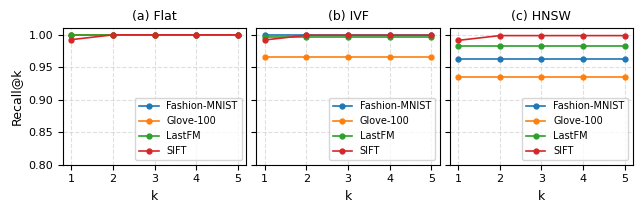

In [21]:
def figure1_k_vs_recall(df):
    index_types = ['flat', 'ivf', 'hnsw']
    panel_titles = ['(a) Flat', '(b) IVF', '(c) HNSW']

    fig, axes = plt.subplots(1, 3, figsize=(6.5, 2.2), sharey=True)

    for ax, index_type, title in zip(axes, index_types, panel_titles):
        filtered = (
            df[(df['index_type'] == index_type) & (df['k'] == 5)]
            .groupby('dataset').first().reset_index()
        )
        # filter ny_times for all types for now
        filtered = filtered[filtered["dataset"] != "ny_times"]
        for _, row in filtered.iterrows():
            recall_values = parse_recall(row['recall'])
            ks = list(range(1, len(recall_values) + 1))
            label = DATASET_PRETTY.get(row['dataset'], row['dataset'])
            ax.plot(ks, recall_values, marker='o', markersize=3.5, linewidth=1.2, label=label)

        ax.set_xlabel('k')
        ax.set_xticks([1, 2, 3, 4, 5])
        ax.set_ylim(0.8, 1.01)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.set_title(title)
        ax.legend(loc='lower right', fontsize=7, framealpha=0.8)

    axes[0].set_ylabel('Recall@k')
    plt.tight_layout(w_pad=0.4)
    plt.savefig(os.path.join(OUTPUT_DIR, 'k_vs_recall.pdf'), format='pdf', bbox_inches='tight')
    plt.show()


figure1_k_vs_recall(df)

## Figure 2: Recall@5 vs QPS

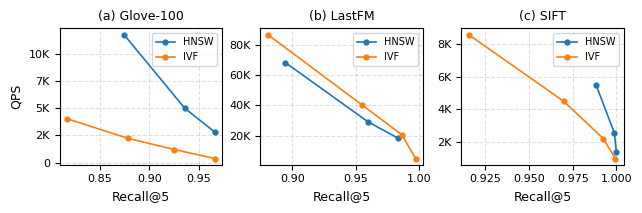

In [12]:
def figure2_recall_vs_qps(df):
    DATASETS = ['glove_100', 'last_fm', 'sift']
    CHOSEN_NLIST = {'glove_100': 1088, 'last_fm': 2163, 'sift': 1000}

    df2 = df.copy()
    df2['recall_list'] = df2['recall'].apply(parse_recall)
    df2['recall_at_5'] = df2['recall_list'].apply(lambda x: x[4] if len(x) >= 5 else None)
    df2 = df2.dropna(subset=['recall_at_5', 'qps', 'index_type'])

    fmt_k = FuncFormatter(lambda x, _: f'{int(x/1000)}K' if abs(x) >= 1000 else str(int(x)))
    fig, axes = plt.subplots(1, 3, figsize=(6.5, 2.2))

    for i, (ax, dataset) in enumerate(zip(axes, DATASETS)):
        dataset_df = df2[df2['dataset'] == dataset]
        for index_type, group in dataset_df.groupby('index_type'):
            if index_type == 'flat':
                continue
            group = group.sort_values('recall_at_5')
            if index_type == 'ivf':
                subset = group[(group['k'] == 5) & (group['nlist'] == CHOSEN_NLIST[dataset])]
            else:
                subset = group[(group['k'] == 5) & (group['ef_construction'] == 160)]
            ax.plot(subset['recall_at_5'], subset['qps'],
                    marker='o', markersize=3.5, linewidth=1.2, label=index_type.upper())

        ax.set_xlabel('Recall@5')
        ax.set_title(f'({chr(97 + i)}) {DATASET_PRETTY[dataset]}')
        ax.yaxis.set_major_formatter(fmt_k)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(loc='best', fontsize=7, framealpha=0.8)

    axes[0].set_ylabel('QPS')
    plt.tight_layout(w_pad=0.4)
    plt.savefig(os.path.join(OUTPUT_DIR, 'recall_vs_qps.pdf'), format='pdf', bbox_inches='tight')
    plt.show()


figure2_recall_vs_qps(df)

## Figure 3: Latency vs Recall@1

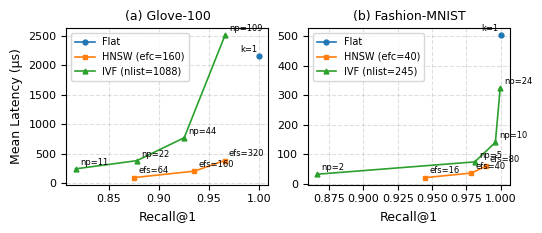

In [22]:
def figure3_latency_vs_recall(df):
    DATASETS = ['glove_100', 'fashion_mnist']

    df3 = df.copy()
    df3['recall_list'] = df3['recall'].apply(parse_recall)
    df3['recall_at_1'] = df3['recall_list'].apply(lambda x: x[0])
    df3 = df3.dropna(subset=['mean_latency_us', 'recall_at_1'])

    fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.4))

    for i, (ax, dataset) in enumerate(zip(axes, DATASETS)):
        dataset_df = df3[df3['dataset'] == dataset]

        flat_df = dataset_df[dataset_df['index_type'] == 'flat'].sort_values('k')
        # Pick only k=1 for flat since it's the only one that makes sense
        flat_df = flat_df[flat_df["k"] == 1]
        if not flat_df.empty:
            ax.plot(flat_df['recall_at_1'], flat_df['mean_latency_us'],
                    marker='o', markersize=3.5, linewidth=1.2, label='Flat')
            for _, row in flat_df.iterrows():
                ax.annotate(f"k={int(row['k'])}", (row['recall_at_1'], row['mean_latency_us']),
                            textcoords='offset points', xytext=(-14, 3), fontsize=6)

        hnsw_df = dataset_df[(dataset_df['index_type'] == 'hnsw') & (dataset_df['k'] == 1)]
        if not hnsw_df.empty:
            for efc, group in hnsw_df.groupby('ef_construction'):
                group = group.sort_values('ef_search')
                ax.plot(group['recall_at_1'], group['mean_latency_us'],
                        marker='s', markersize=3.5, linewidth=1.2, label=f'HNSW (efc={int(efc)})')
                for _, row in group.iterrows():
                    ax.annotate(f"efs={int(row['ef_search'])}",
                                (row['recall_at_1'], row['mean_latency_us']),
                                textcoords='offset points', xytext=(3, 3), fontsize=6)
                break

        ivf_df = dataset_df[(dataset_df['index_type'] == 'ivf') & (dataset_df['k'] == 1)]
        if not ivf_df.empty:
            for nlist, group in ivf_df.groupby('nlist'):
                group = group.sort_values('nprobe')
                ax.plot(group['recall_at_1'], group['mean_latency_us'],
                        marker='^', markersize=3.5, linewidth=1.2, label=f'IVF (nlist={int(nlist)})')
                for _, row in group.iterrows():
                    ax.annotate(f"np={int(row['nprobe'])}",
                                (row['recall_at_1'], row['mean_latency_us']),
                                textcoords='offset points', xytext=(3, 3), fontsize=6)
                break

        ax.set_title(f'({chr(97 + i)}) {DATASET_PRETTY[dataset]}')
        ax.set_xlabel('Recall@1')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(loc='best', fontsize=7, framealpha=0.8)

    axes[0].set_ylabel('Mean Latency (μs)')
    plt.tight_layout(w_pad=0.4)
    plt.savefig(os.path.join(OUTPUT_DIR, 'latency_vs_recall.pdf'), format='pdf', bbox_inches='tight')
    plt.show()


figure3_latency_vs_recall(df)

## Figure 4: Memory Usage

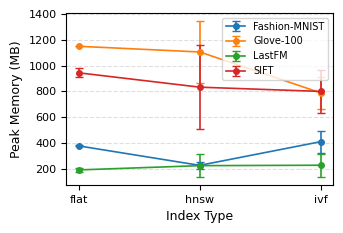

In [6]:
def figure4_memory(df):
    stats = (
        df.groupby(['dataset', 'index_type'])['memory_mb']
        .agg(['mean', 'var']).reset_index()
    )
    
    # Remove ny_times for all types for now
    stats = stats[stats["dataset"] != "ny_times"]

    fig, ax = plt.subplots(figsize=(3.5, 2.4))

    for dataset, group in stats.groupby('dataset'):
        ax.errorbar(
            group['index_type'], group['mean'],
            yerr=group['var'] ** 0.5,
            marker='o', markersize=4, capsize=3, linewidth=1.2,
            label=DATASET_PRETTY.get(dataset, dataset)
        )

    ax.set_xlabel('Index Type')
    ax.set_ylabel('Peak Memory (MB)')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=7, framealpha=0.8)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'memory.pdf'), format='pdf', bbox_inches='tight')
    plt.show()


figure4_memory(df)

## Figure 5: Time Breakdowns — Fashion-MNIST

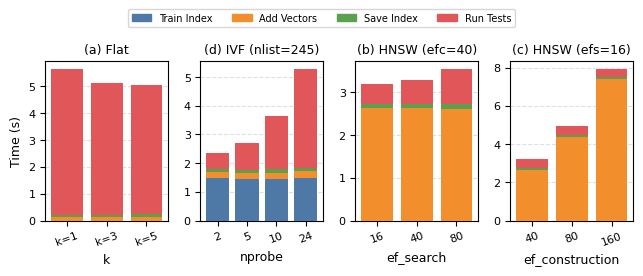

In [25]:
def figure5_time_breakdowns(df):
    dataset_df = df[df['dataset'] == 'fashion_mnist']

    COLORS = {
        'Train Index': '#4e79a7',
        'Add Vectors': '#f28e2b',
        'Save Index':  '#59a14f',
        'Run Tests':   '#e15759',
    }

    def plot_bars(ax, group_df, x_labels, include_train=False):
        bottom = [0.0] * len(x_labels)
        segments = []
        if include_train:
            segments.append(('Train Index', group_df['training_time_sec'].tolist()))
        segments += [
            ('Add Vectors', group_df['add_time_sec'].tolist()),
            ('Save Index',  group_df['save_time_sec'].tolist()),
            ('Run Tests',   group_df['test_time_sec'].tolist()),
        ]
        for label, values in segments:
            ax.bar(x_labels, values, bottom=bottom, color=COLORS[label], label=label, zorder=3)
            bottom = [b + v for b, v in zip(bottom, values)]

    fig, axes = plt.subplots(1, 4, figsize=(6.5, 2.5))

    flat_df = dataset_df[dataset_df['index_type'] == 'flat'].sort_values('k')
    plot_bars(axes[0], flat_df, [f'k={int(k)}' for k in flat_df['k']])
    axes[0].set_title('(a) Flat')
    axes[0].set_xlabel('k')
    
    ivf_df = dataset_df[(dataset_df['index_type'] == 'ivf') & (dataset_df['k'] == 5)]
    for nlist, group in ivf_df.groupby('nlist'):
        group = group.sort_values('nprobe')
        plot_bars(axes[1], group, [str(int(v)) for v in group['nprobe']], include_train=True)
        axes[1].set_title(f'(d) IVF (nlist={int(nlist)})')
        axes[1].set_xlabel('nprobe')
        break

    hnsw_df = dataset_df[(dataset_df['index_type'] == 'hnsw') & (dataset_df['k'] == 5)]

    for efc, group in hnsw_df.groupby('ef_construction'):
        group = group.sort_values('ef_search')
        plot_bars(axes[2], group, [str(int(v)) for v in group['ef_search']])
        axes[2].set_title(f'(b) HNSW (efc={int(efc)})')
        axes[2].set_xlabel('ef_search')
        break

    for efs, group in hnsw_df.groupby('ef_search'):
        group = group.sort_values('ef_construction')
        plot_bars(axes[3], group, [str(int(v)) for v in group['ef_construction']])
        axes[3].set_title(f'(c) HNSW (efs={int(efs)})')
        axes[3].set_xlabel('ef_construction')
        break

    axes[0].set_ylabel('Time (s)')
    for ax in axes:
        ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
        ax.tick_params(axis='x', rotation=20)

    legend_handles = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
    fig.legend(handles=legend_handles, loc='upper center', ncol=4, fontsize=7,
               bbox_to_anchor=(0.5, 1.1))
    plt.tight_layout(w_pad=0.4)
    plt.savefig(os.path.join(OUTPUT_DIR, 'time_breakdowns.pdf'), format='pdf', bbox_inches='tight')
    plt.show()


figure5_time_breakdowns(df)

---
# Task Benchmark Figures

In [ ]:
TASK_RESULTS_DIR = './results'

def load_task_result(i):
    path = os.path.join(TASK_RESULTS_DIR, f'trivia_qa_{i}', 'metrics.json')
    with open(path) as f:
        return json.load(f)

all_task_results = [load_task_result(i) for i in range(32)]
print(f'Loaded {len(all_task_results)} task results')

# Short paper labels for all 32 configs
ALL_TASK_LABELS = [
    'Baseline',           # 0
    'Emb. MiniLM-L12',   # 1
    'Emb. XNNPACK',      # 2
    'Emb. NNAPI',        # 3
    'IVF',               # 4
    'IVF k=1',           # 5
    'IVF k=5',           # 6
    'IVF nl=497',        # 7
    'IVF nl=497 k=1',    # 8
    'IVF nl=497 k=5',    # 9
    'IVF nl=995',        # 10
    'IVF nl=995 k=1',    # 11
    'IVF nl=995 k=5',    # 12
    'IVF np=4',          # 13
    'IVF np=4 k=1',      # 14
    'IVF np=4 k=5',      # 15
    'IVF np=49',         # 16
    'IVF np=49 k=1',     # 17
    'IVF np=49 k=5',     # 18
    'HNSW',              # 19
    'HNSW k=1',          # 20
    'HNSW k=5',          # 21
    'HNSW M=24',         # 22
    'HNSW M=24 k=1',     # 23
    'HNSW M=24 k=5',     # 24
    'HNSW M=32',         # 25
    'HNSW M=32 k=1',     # 26
    'HNSW M=32 k=5',     # 27
    'LLM Qwen2.5-1.5B',  # 28
    'LLM (Q4)',          # 29
    'LLM (XNNPACK)',     # 30
    'LLM (NNAPI)',       # 31
]

THROUGHPUT_IDX = [0, 28, 29, 30, 31]
DEFAULT_IDX    = [0, 1, 2, 3, 4, 19, 28, 29, 30,31]

Loaded 32 task results


## Figure 6: Decoding Throughput

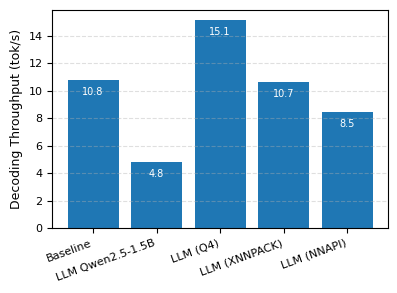

In [42]:
def figure6_throughput(all_results, all_labels, indices):
    results = [all_results[i] for i in indices]
    labels  = [all_labels[i]  for i in indices]

    tps = [r['task']['generation_metrics']['decoding_speed_toks_per_sec']['avg']
           for r in results]

    fig, ax = plt.subplots(figsize=(0.65 * len(labels) + 0.8, 3.0))
    bars = ax.bar(labels, tps)

    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h - 0.5,
                f'{h:.1f}', ha='center', va='top', fontsize=7, color='white')

    ax.set_ylabel('Decoding Throughput (tok/s)')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'task_throughput.pdf'), format='pdf', bbox_inches='tight')
    plt.show()


figure6_throughput(all_task_results, ALL_TASK_LABELS, THROUGHPUT_IDX)

## Figure 7: Time to First Token Breakdown

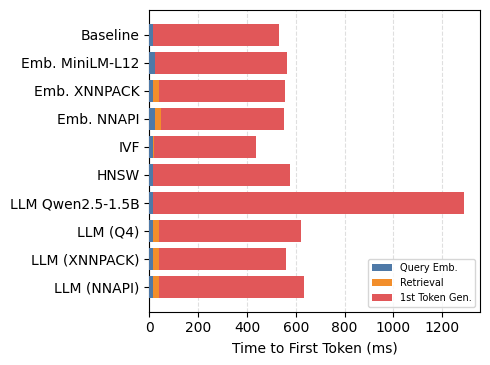

In [ ]:
def figure7_ttft_breakdown(all_results, all_labels, indices):
    results = [all_results[i] for i in indices]
    labels  = [all_labels[i]  for i in indices]

    query_ms, retrieve_ms_list, gen_ms_list = [], [], []
    for r in results:
        gm = r['task']['generation_metrics']
        q   = gm['query_embeddings_ms']['avg']
        ret = gm['retrieve_top_k_docs_ns']['avg'] / 1e6
        gen = max(gm['ttft_ms']['avg'] - q - ret, 0)
        query_ms.append(q)
        retrieve_ms_list.append(ret)
        gen_ms_list.append(gen)

    COLORS = {
        'Query Emb.':    '#4e79a7',
        'Retrieval':     '#f28e2b',
        '1st Token Gen.':'#e15759',
    }
    stacks = [('Query Emb.', query_ms), ('Retrieval', retrieve_ms_list), ('1st Token Gen.', gen_ms_list)]

    fig, ax = plt.subplots(figsize=(5.0, 0.32 * len(labels) + 0.55))
    left = [0.0] * len(labels)
    for name, vals in stacks:
        ax.barh(labels, vals, left=left, color=COLORS[name], label=name, zorder=3)
        left = [l + v for l, v in zip(left, vals)]

    ax.invert_yaxis()
    ax.set_xlabel('Time to First Token (ms)')
    ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)
    ax.legend(loc='lower right', fontsize=7, framealpha=0.8)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'task_ttft_breakdown.pdf'), format='pdf', bbox_inches='tight')
    plt.show()


figure7_ttft_breakdown(all_task_results, ALL_TASK_LABELS, DEFAULT_IDX)

## Figure 8: Peak Memory

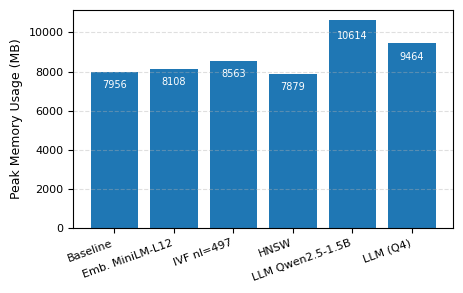

In [44]:
def figure8_peak_memory(all_results, all_labels, indices):
    results = [all_results[i] for i in indices]
    labels  = [all_labels[i]  for i in indices]

    baseline_mem_before = results[0]['hardware']['memory']['beforeMB']
    deltas = [r['hardware']['memory']['peakMB'] for r in results]

    fig, ax = plt.subplots(figsize=(0.65 * len(indices) + 0.8, 3.0))
    bars = ax.bar(labels, deltas)

    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h * 0.95,
                f'{h:.0f}', ha='center', va='top', fontsize=7, color='white')

    ax.set_ylabel('Peak Memory Usage (MB)')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'task_peak_memory.pdf'), format='pdf', bbox_inches='tight')
    plt.show()


figure8_peak_memory(all_task_results, ALL_TASK_LABELS, [0, 1, 7, 19, 28, 29,])

## Figure 9: Contains Accuracy

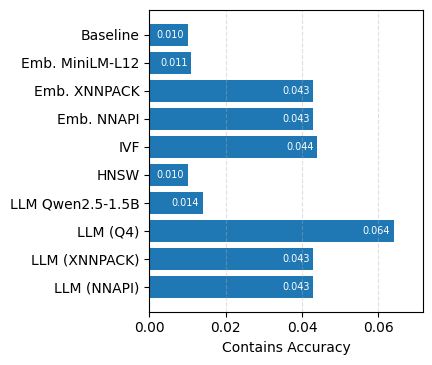

In [ ]:
def figure9_accuracy(all_results, all_labels, indices):
    results = [all_results[i] for i in indices]
    labels  = [all_labels[i]  for i in indices]

    contains = [r['task']['generation_metrics']['accuracy']['contains'] for r in results]

    fig, ax = plt.subplots(figsize=(4.5, 0.32 * len(labels) + 0.55))
    bars = ax.barh(labels, contains)
    ax.invert_yaxis()

    for bar in bars:
        w = bar.get_width()
        ax.text(w - 0.001, bar.get_y() + bar.get_height() / 2,
                f'{w:.3f}', va='center', ha='right', fontsize=7, color='white')

    ax.set_xlabel('Contains Accuracy')
    ax.set_xlim(0, max(contains) * 1.12)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'task_accuracy.pdf'), format='pdf', bbox_inches='tight')
    plt.show()


figure9_accuracy(all_task_results, ALL_TASK_LABELS, DEFAULT_IDX)

## Figure 10: Pipeline Time Breakdown

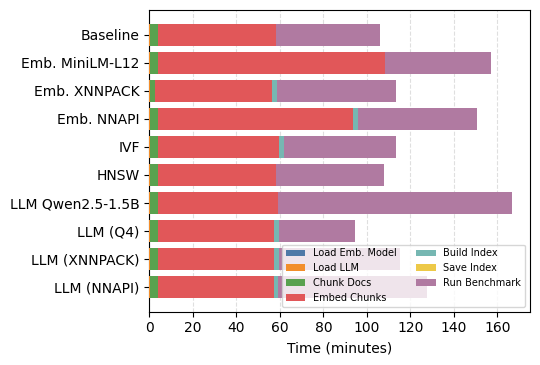

In [ ]:
def figure10_pipeline_breakdown(all_results, all_labels, indices):
    results = [all_results[i] for i in indices]
    labels  = [all_labels[i]  for i in indices]

    COLORS = {
        'Load Emb. Model': '#4e79a7',
        'Load LLM':        '#f28e2b',
        'Chunk Docs':      '#59a14f',
        'Embed Chunks':    '#e15759',
        'Build Index':     '#76b7b2',
        'Save Index':      '#edc948',
        'Run Benchmark':   '#b07aa1',
    }
    segments = {k: [] for k in COLORS}
    for r in results:
        o  = r['overall']
        fm = r['task']['faiss_metrics']
        gm = r['task']['generation_metrics']
        segments['Load Emb. Model'].append(o['embeddingInitTimeMs'] / 60000)
        segments['Load LLM'].append(o['llmInitTimeMs'] / 60000)
        segments['Chunk Docs'].append(fm['chunkingTimeNs']['totalNs'] / 1e6 / 60000)
        segments['Embed Chunks'].append(fm['embeddingTimeNs']['totalNs'] / 1e6 / 60000)
        segments['Build Index'].append(fm['addTimeNs']['totalNs'] / 1e6 / 60000)
        segments['Save Index'].append(fm['saveTimeNs'] / 1e6 / 60000)
        segments['Run Benchmark'].append(gm['overall_duration_ms'] / 60000)

    fig, ax = plt.subplots(figsize=(5.5, 0.32 * len(labels) + 0.55))
    left = [0.0] * len(labels)
    for name, color in COLORS.items():
        vals = segments[name]
        ax.barh(labels, vals, left=left, color=color, label=name, zorder=3)
        left = [l + v for l, v in zip(left, vals)]

    ax.invert_yaxis()
    ax.set_xlabel('Time (minutes)')
    ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)
    ax.legend(loc='lower right', fontsize=7, framealpha=0.8, ncol=2)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'task_pipeline_breakdown.pdf'), format='pdf', bbox_inches='tight')
    plt.show()


figure10_pipeline_breakdown(all_task_results, ALL_TASK_LABELS, DEFAULT_IDX)